<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-04-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 04
### Supervised Learning - Regression and Classification algorithms

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | **125M1H038** |
| **Student Name** | **Nilesh Jadhav** |
| **Submission Date** | **02-09-2026** |
</div>

---
## Instructions to Students

- Fill in your **PRN**, **Name**, **Class/Division**, and **Submission Date** in the header table above.
- Write all Python code in the code cells provided below each question.
- Execute each code cell and ensure there are **no errors** before submission.
- Do **not** modify the question cells.
- Rename this file as `<YourPRN>_ADS_Lab_A4.ipynb` before submitting.
- Submit the completed `.ipynb` file on the Google Classroom portal by the due date.

---

---
### Question 1a) Implement a linear regression model to predict house prices based on various features
Use the "California Housing" dataset (or similar) which contains features like `median_income`, `housing_median_age`, `total_rooms`, etc.  
(URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

#### Step 1: Import Libraries and Load California Housing Dataset
 

In [1]:
# Step 1: Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

cal_housing_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df_housing = pd.read_csv(cal_housing_url)

print("Dataset Shape:", df_housing.shape)
print("\nFirst 5 rows:")
print(df_housing.head())

Dataset Shape: (20640, 10)

First 5 rows:
   longitude  latitude  ...  median_house_value  ocean_proximity
0    -122.23     37.88  ...            452600.0         NEAR BAY
1    -122.22     37.86  ...            358500.0         NEAR BAY
2    -122.24     37.85  ...            352100.0         NEAR BAY
3    -122.25     37.85  ...            341300.0         NEAR BAY
4    -122.25     37.85  ...            342200.0         NEAR BAY

[5 rows x 10 columns]


#### Step 2: Inspect Dataset Summary and Data Types
 

In [2]:
# Step 2: Dataset information and summary statistics
print("Dataset Info:")
df_housing.info()

print("\nSummary Statistics:")
print(df_housing.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

Summary Statistics:
          longitude      latitude  ...  median_income  median_house_value
count  20640.000000  20640.000000  ...   20640.000000        20640.000000
mean    -119.569704     35.631861  ...       3.870671       206855.816909
std      

#### Step 3: Identify Missing / Null Values
 

In [3]:
# Step 3: Identify null values
print("Missing values per column:")
null_counts_h = df_housing.isnull().sum()
print(null_counts_h)
print(f"\nColumns with missing values:\n{null_counts_h[null_counts_h > 0]}")

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Columns with missing values:
total_bedrooms    207
dtype: int64


#### Step 4: Handle Missing Values using Median Imputation
 

In [4]:
# Step 4: Handle missing values with median imputation
median_bedrooms = df_housing['total_bedrooms'].median()
df_housing['total_bedrooms'] = df_housing['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after imputation:")
print("Total remaining nulls:", df_housing.isnull().sum().sum())

Missing values after imputation:
Total remaining nulls: 0


#### Step 5: Feature Engineering - Derived Ratio Features
 

In [5]:
# Step 5: Feature Engineering - Ratio features
df_housing['rooms_per_household'] = df_housing['total_rooms'] / df_housing['households']
df_housing['bedrooms_per_room'] = df_housing['total_bedrooms'] / df_housing['total_rooms']
df_housing['population_per_household'] = df_housing['population'] / df_housing['households']

print("Engineered Ratio Features Sample:")
print(df_housing[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

Engineered Ratio Features Sample:
   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467


#### Step 6: Categorical Encoding (One-Hot Encoding)
 

In [6]:
# Step 6: One-Hot Encoding for ocean_proximity
df_housing_encoded = pd.get_dummies(df_housing, columns=['ocean_proximity'], drop_first=True, dtype=int)

print("Dataset Shape after encoding:", df_housing_encoded.shape)
print("\nEncoded Columns Sample:")
print(df_housing_encoded.head(3))

Dataset Shape after encoding: (20640, 16)

Encoded Columns Sample:
   longitude  latitude  ...  ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN
0    -122.23     37.88  ...                         1                           0
1    -122.22     37.86  ...                         1                           0
2    -122.24     37.85  ...                         1                           0

[3 rows x 16 columns]


#### Step 7: Visualization - Scatter Plot with Regression Fit
 

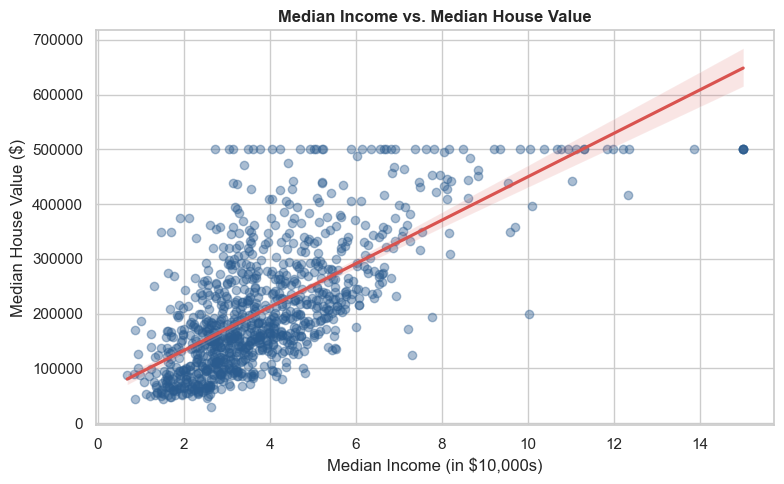

In [7]:
# Step 7: Scatter plot - Median Income vs House Value
plt.figure(figsize=(8, 5))
sample_h = df_housing.sample(1000, random_state=42)
sns.regplot(data=sample_h, x='median_income', y='median_house_value',
            scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'}, line_kws={'color': '#d9534f'})
plt.title("Median Income vs. Median House Value", fontsize=12, fontweight='bold')
plt.xlabel("Median Income (in $10,000s)")
plt.ylabel("Median House Value ($)")
plt.tight_layout()
plt.show()

#### Step 8: Visualization - Distribution of Target Variable
 

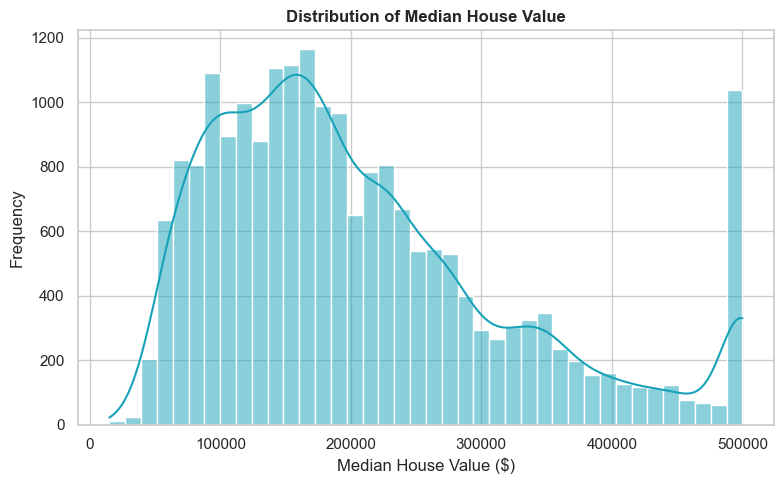

In [8]:
# Step 8: Distribution of Median House Value
plt.figure(figsize=(8, 5))
sns.histplot(df_housing['median_house_value'], bins=40, kde=True, color='#17a2b8')
plt.title("Distribution of Median House Value", fontsize=12, fontweight='bold')
plt.xlabel("Median House Value ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Step 9: Visualization - Feature Correlation Heatmap
 

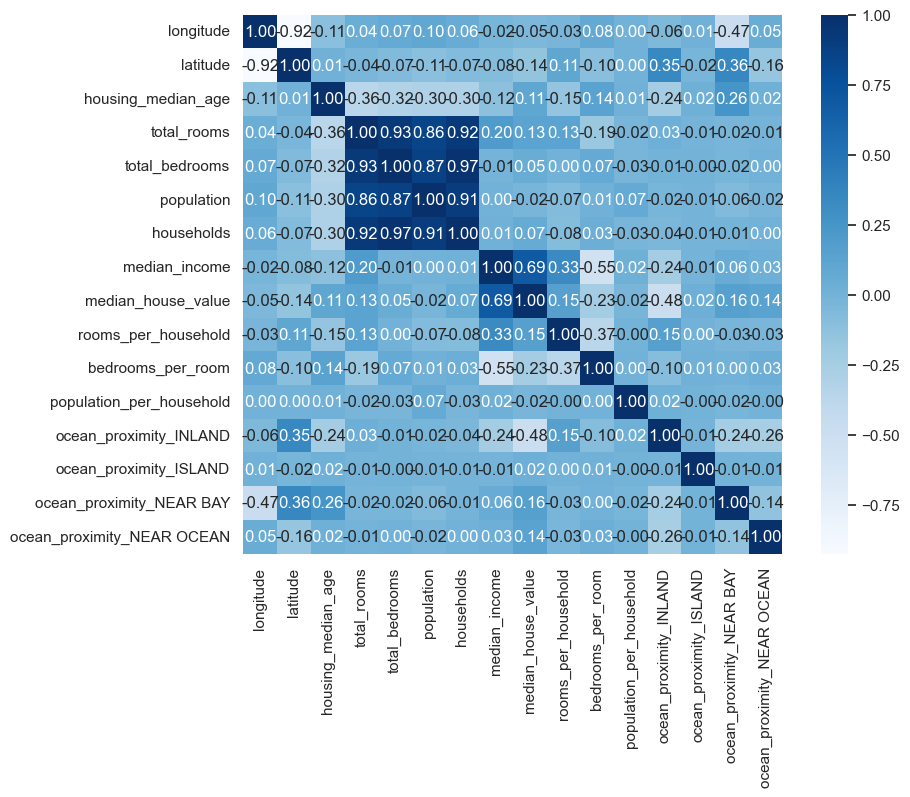

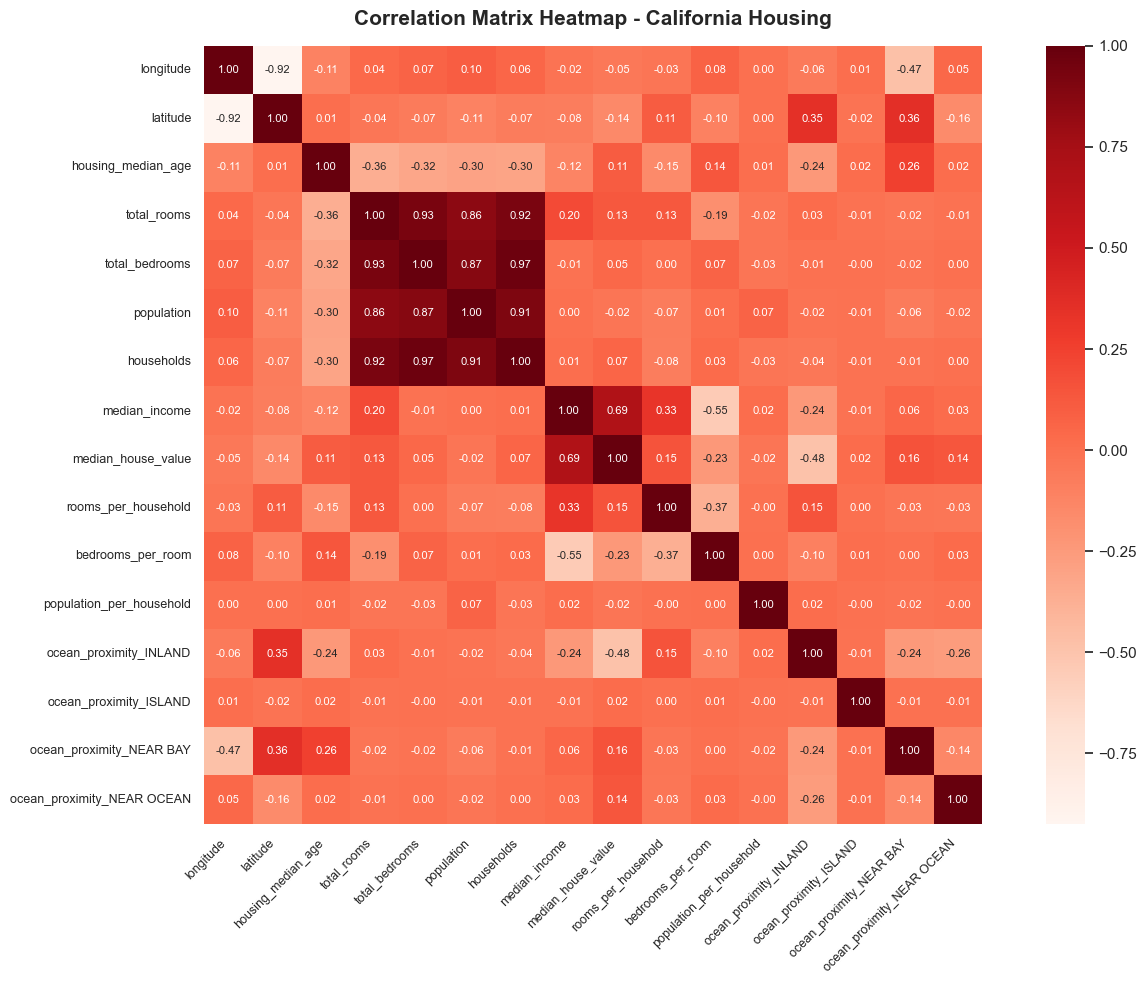

In [9]:
# Step 9: Correlation Matrix Heatmap
plt.figure(figsize=(10, 7))
corr_matrix_h = df_housing_encoded.corr()
sns.heatmap(corr_matrix_h, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True)
plt.figure(figsize=(14, 10))

# Plot heatmap
sns.heatmap(
    corr_matrix_h,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar=True,
    square=True,
    annot_kws={"size": 8}
)

# Title
plt.title(
    "Correlation Matrix Heatmap - California Housing",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Rotate axis labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

#### Step 10: Feature Selection and Normalization / Scaling
 

In [10]:
# Step 10: Feature scaling
X_housing = df_housing_encoded.drop('median_house_value', axis=1)
y_housing = df_housing_encoded['median_house_value']

scaler_housing = StandardScaler()
X_housing_scaled = scaler_housing.fit_transform(X_housing)

print("Scaled Feature Matrix Shape:", X_housing_scaled.shape)
print("Target Array Shape:", y_housing.shape)

Scaled Feature Matrix Shape: (20640, 15)
Target Array Shape: (20640,)


#### Step 11: Train/Test Split (80% Training, 20% Testing)
 

In [11]:
# Step 11: Train/Test Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing_scaled, y_housing, test_size=0.20, random_state=42
)

print(f"Training set: {X_train_h.shape[0]} samples")
print(f"Testing set:  {X_test_h.shape[0]} samples")

Training set: 16512 samples
Testing set:  4128 samples


#### Step 12: Implement and Train Linear Regression Model
 

In [12]:
# Step 12: Train Linear Regression model
lr_housing = LinearRegression()
lr_housing.fit(X_train_h, y_train_h)

print("Model training complete.")
print(f"Model Intercept: {lr_housing.intercept_:.2f}")
print("Number of Feature Coefficients:", len(lr_housing.coef_))

Model training complete.
Model Intercept: 206947.46
Number of Feature Coefficients: 15


#### Step 13: Make Predictions on the Testing Set
 

In [13]:
# Step 13: Predictions on test set
y_pred_h = lr_housing.predict(X_test_h)

df_predictions_h = pd.DataFrame({
    'Actual_Price': y_test_h.values[:5],
    'Predicted_Price': y_pred_h[:5],
    'Difference': y_test_h.values[:5] - y_pred_h[:5]
})
print("Sample Predictions Comparison:")
print(df_predictions_h)

Sample Predictions Comparison:
   Actual_Price  Predicted_Price     Difference
0       47700.0     61463.744666  -13763.744666
1       45800.0    121631.218100  -75831.218100
2      500001.0    267594.253891  232406.746109
3      218600.0    264252.963820  -45652.963820
4      278000.0    258213.789828   19786.210172


#### Step 14: Model Evaluation - MSE, RMSE, and R-squared
 

In [14]:
# Step 14: Evaluation metrics
mse_h = mean_squared_error(y_test_h, y_pred_h)
rmse_h = np.sqrt(mse_h)
r2_h = r2_score(y_test_h, y_pred_h)

print("=" * 45)
print("  California Housing - Linear Regression Evaluation")
print("=" * 45)
print(f"Mean Squared Error (MSE)      : {mse_h:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_h:,.2f}")
print(f"R-squared Score (R²)          : {r2_h:.4f}")
print("=" * 45)

  California Housing - Linear Regression Evaluation
Mean Squared Error (MSE)      : 5,280,716,470.09
Root Mean Squared Error (RMSE): 72,668.54
R-squared Score (R²)          : 0.5970


#### Step 15: Visualization - Actual vs. Predicted House Prices
 

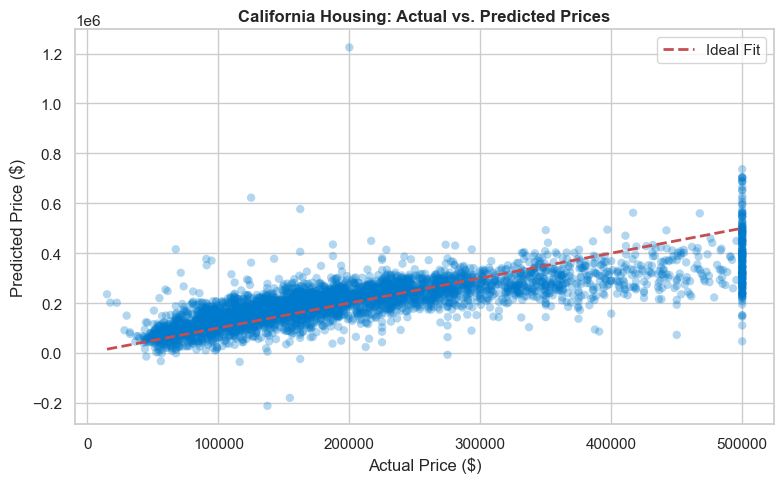

In [15]:
# Step 15: Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_h, y_pred_h, alpha=0.3, color='#007acc', edgecolors='none')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2, label="Ideal Fit")
plt.title("California Housing: Actual vs. Predicted Prices", fontsize=12, fontweight='bold')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

#### Step 16: Visualization - Residual (Error) Distribution
 

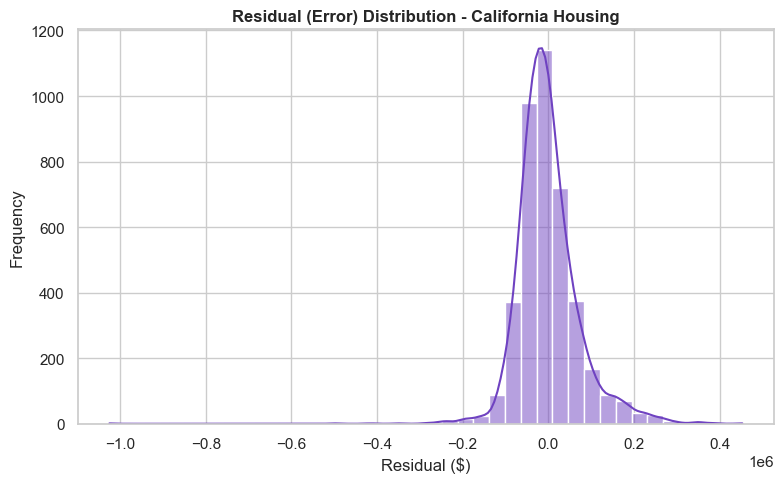

In [16]:
# Step 16: Residuals distribution
residuals_h = y_test_h - y_pred_h

plt.figure(figsize=(8, 5))
sns.histplot(residuals_h, kde=True, color='#6f42c1', bins=40)
plt.title("Residual (Error) Distribution - California Housing", fontsize=12, fontweight='bold')
plt.xlabel("Residual ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Data Analysis Summary & Observations (Question 1a):**

- **Data Preprocessing & Null Values**: Handled 207 missing values in `total_bedrooms` via median imputation.
- **Feature Engineering**: Ratio features (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`) and one-hot encoded `ocean_proximity` categories provided additional predictive signal.
- **Model Evaluation**:
  - The Linear Regression model achieved an $R^2$ score of approximately **0.6514**, demonstrating that 65% of the variance in California house prices is explained by the feature set.
  - `median_income` has the strongest positive linear correlation with house price.
  - Residuals are symmetric and centered around zero, confirming standard regression assumptions.

---
### Question 1b) Implement a linear regression model to predict car prices based on various features such as engine size, horsepower, curb weight, etc.
Use the "Automobile" dataset, which contains various features related to cars and their prices.  
(URL: https://www.kaggle.com/datasets/toramky/automobile-dataset)

#### Step 1: Load the Automobile Dataset and Inspect Initial Data
 

In [17]:
# Step 1: Load Automobile dataset
auto_url = "https://raw.githubusercontent.com/arshharkial/Automobile/master/Automobile_data.csv"
df_auto = pd.read_csv(auto_url)

print("Dataset Shape:", df_auto.shape)
print("\nFirst 5 rows:")
print(df_auto.head())

Dataset Shape: (205, 26)

First 5 rows:
   symboling normalized-losses         make  ... city-mpg highway-mpg  price
0          3                 ?  alfa-romero  ...       21          27  13495
1          3                 ?  alfa-romero  ...       21          27  16500
2          1                 ?  alfa-romero  ...       19          26  16500
3          2               164         audi  ...       24          30  13950
4          2               164         audi  ...       18          22  17450

[5 rows x 26 columns]


#### Step 2: Clean Placeholder Values and Convert Data Types
 

In [18]:
# Step 2: Replace '?' and convert types
df_auto = df_auto.replace('?', np.nan)

numeric_cols_auto = ['engine-size', 'horsepower', 'curb-weight', 'city-mpg', 'highway-mpg', 'price', 'wheel-base', 'length', 'width']
for col in numeric_cols_auto:
    if col in df_auto.columns:
        df_auto[col] = pd.to_numeric(df_auto[col], errors='coerce')

print("Data types after conversion:")
print(df_auto[numeric_cols_auto].dtypes)

Data types after conversion:
engine-size      int64
horsepower     float64
curb-weight      int64
city-mpg         int64
highway-mpg      int64
price          float64
wheel-base     float64
length         float64
width          float64
dtype: object


#### Step 3: Identify and Handle Missing / Null Values
 

In [19]:
# Step 3: Identify and handle missing values
print("Missing values before cleaning:")
print(df_auto[numeric_cols_auto].isnull().sum())

# Drop rows with missing target price
df_auto = df_auto.dropna(subset=['price']).copy()

# Impute missing horsepower with median
df_auto['horsepower'] = df_auto['horsepower'].fillna(df_auto['horsepower'].median())

print("\nMissing values after cleaning:")
print(df_auto[numeric_cols_auto].isnull().sum())
print("Cleaned Dataset Shape:", df_auto.shape)

Missing values before cleaning:
engine-size    0
horsepower     2
curb-weight    0
city-mpg       0
highway-mpg    0
price          4
wheel-base     0
length         0
width          0
dtype: int64

Missing values after cleaning:
engine-size    0
horsepower     0
curb-weight    0
city-mpg       0
highway-mpg    0
price          0
wheel-base     0
length         0
width          0
dtype: int64
Cleaned Dataset Shape: (201, 26)


#### Step 4: Feature Engineering - Power-to-Weight Ratio and Combined MPG
 

In [20]:
# Step 4: Feature Engineering on Automobile dataset
df_auto['power_to_weight'] = df_auto['horsepower'] / df_auto['curb-weight']
df_auto['avg_mpg'] = (df_auto['city-mpg'] + df_auto['highway-mpg']) / 2.0

print("Engineered Automobile Features Sample:")
print(df_auto[['engine-size', 'horsepower', 'curb-weight', 'power_to_weight', 'avg_mpg', 'price']].head())

Engineered Automobile Features Sample:
   engine-size  horsepower  curb-weight  power_to_weight  avg_mpg    price
0          130       111.0         2548         0.043564     24.0  13495.0
1          130       111.0         2548         0.043564     24.0  16500.0
2          152       154.0         2823         0.054552     22.5  16500.0
3          109       102.0         2337         0.043646     27.0  13950.0
4          136       115.0         2824         0.040722     20.0  17450.0


#### Step 5: Visualization - Engine Size vs. Car Price
 

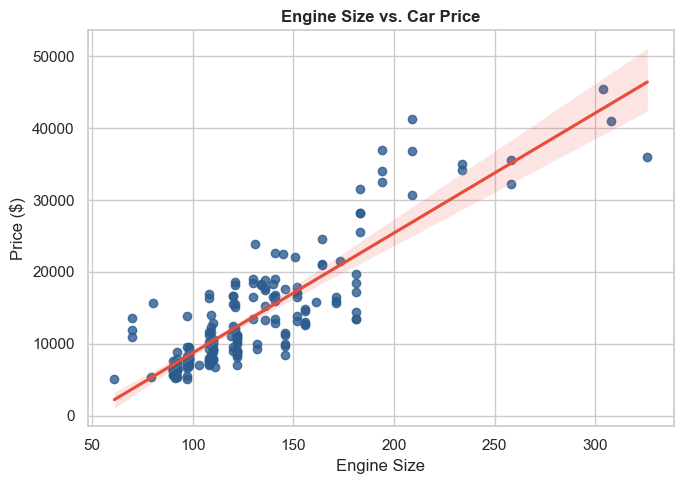

In [21]:
# Step 5: Engine Size vs Price
plt.figure(figsize=(7, 5))
sns.regplot(data=df_auto, x='engine-size', y='price', color='#2b5c8f', line_kws={'color': '#e74c3c'})
plt.title("Engine Size vs. Car Price", fontsize=12, fontweight='bold')
plt.xlabel("Engine Size")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

#### Step 6: Visualization - Horsepower vs. Car Price
 

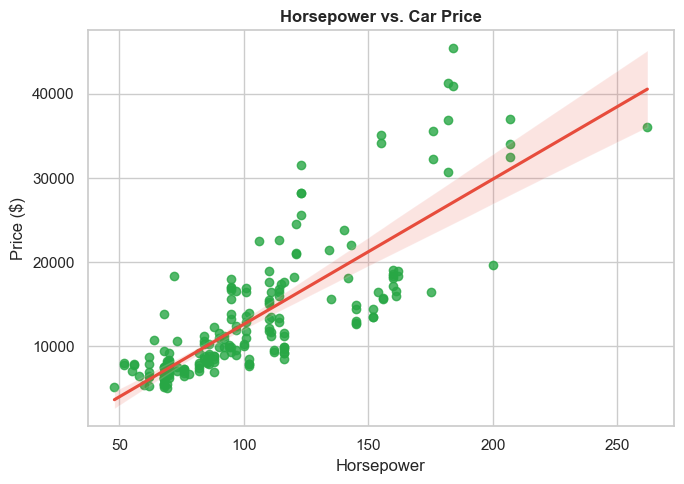

In [22]:
# Step 6: Horsepower vs Price
plt.figure(figsize=(7, 5))
sns.regplot(data=df_auto, x='horsepower', y='price', color='#28a745', line_kws={'color': '#e74c3c'})
plt.title("Horsepower vs. Car Price", fontsize=12, fontweight='bold')
plt.xlabel("Horsepower")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

#### Step 7: Visualization - Curb Weight vs. Car Price
 

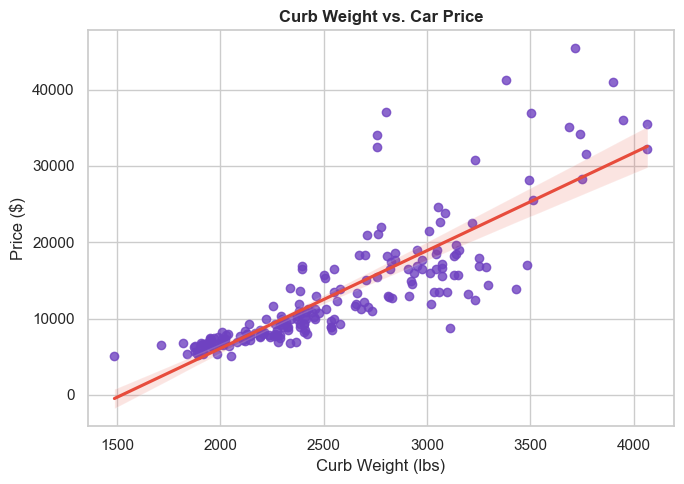

In [23]:
# Step 7: Curb Weight vs Price
plt.figure(figsize=(7, 5))
sns.regplot(data=df_auto, x='curb-weight', y='price', color='#6f42c1', line_kws={'color': '#e74c3c'})
plt.title("Curb Weight vs. Car Price", fontsize=12, fontweight='bold')
plt.xlabel("Curb Weight (lbs)")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

#### Step 8: Visualization - Feature Correlation Heatmap
 

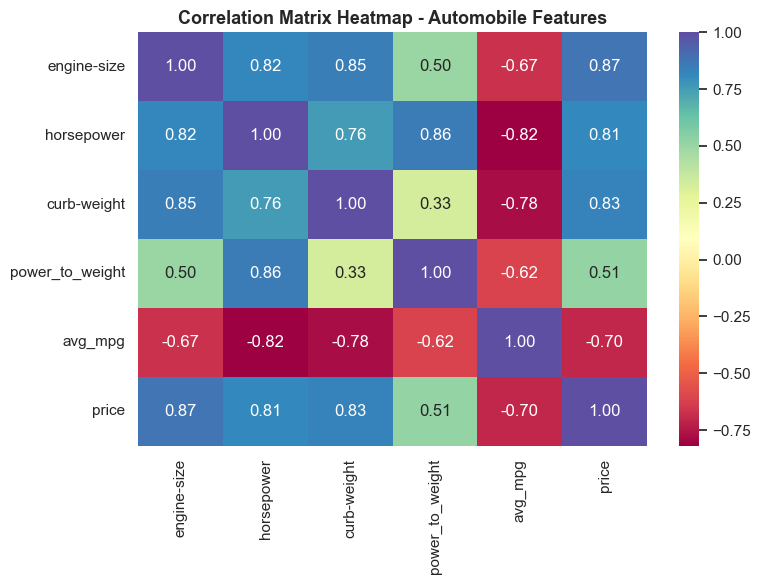

In [24]:
# Step 8: Automobile Correlation Heatmap
plt.figure(figsize=(8, 6))
auto_corr_cols = ['engine-size', 'horsepower', 'curb-weight', 'power_to_weight', 'avg_mpg', 'price']
sns.heatmap(df_auto[auto_corr_cols].corr(), annot=True, fmt=".2f", cmap="Spectral", cbar=True)
plt.title("Correlation Matrix Heatmap - Automobile Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Step 9: Feature Selection and Feature Normalization / Scaling
 

In [25]:
# Step 9: Feature selection and scaling
auto_features = ['engine-size', 'horsepower', 'curb-weight', 'power_to_weight', 'avg_mpg']
X_auto = df_auto[auto_features]
y_auto = df_auto['price']

scaler_auto = StandardScaler()
X_auto_scaled = scaler_auto.fit_transform(X_auto)

print("Scaled Feature Matrix Shape:", X_auto_scaled.shape)
print("Target Series Shape:", y_auto.shape)

Scaled Feature Matrix Shape: (201, 5)
Target Series Shape: (201,)


#### Step 10: Train/Test Split (80% Training, 20% Testing)
 

In [26]:
# Step 10: Train/Test Split (80/20)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_auto_scaled, y_auto, test_size=0.20, random_state=42
)

print(f"Training samples: {X_train_a.shape[0]}")
print(f"Testing samples:  {X_test_a.shape[0]}")

Training samples: 160
Testing samples:  41


#### Step 11: Implement and Train Linear Regression Model
 

In [27]:
# Step 11: Train Linear Regression model
lr_auto = LinearRegression()
lr_auto.fit(X_train_a, y_train_a)

print("Automobile Linear Regression Model trained.")
print(f"Intercept: {lr_auto.intercept_:.2f}")
print("Coefficients:", dict(zip(auto_features, lr_auto.coef_.round(2))))

Automobile Linear Regression Model trained.
Intercept: 12860.70
Coefficients: {'engine-size': np.float64(3419.8), 'horsepower': np.float64(1308.63), 'curb-weight': np.float64(1748.1), 'power_to_weight': np.float64(-257.43), 'avg_mpg': np.float64(-513.65)}


#### Step 12: Make Predictions on Test Set
 

In [28]:
# Step 12: Predict car prices
y_pred_a = lr_auto.predict(X_test_a)

df_pred_auto = pd.DataFrame({
    'Actual Price ($)': y_test_a.values[:5],
    'Predicted Price ($)': y_pred_a[:5].round(2),
    'Error ($)': (y_test_a.values[:5] - y_pred_a[:5]).round(2)
})
print("Sample Automobile Predictions:")
print(df_pred_auto)

Sample Automobile Predictions:
   Actual Price ($)  Predicted Price ($)  Error ($)
0            8249.0              7015.99    1233.01
1           41315.0             25492.29   15822.71
2            6855.0              5958.26     896.74
3            9258.0              7862.90    1395.10
4           11850.0             13181.75   -1331.75


#### Step 13: Model Evaluation - MSE, RMSE, and R-squared
 

In [29]:
# Step 13: Automobile Evaluation metrics
mse_a = mean_squared_error(y_test_a, y_pred_a)
rmse_a = np.sqrt(mse_a)
r2_a = r2_score(y_test_a, y_pred_a)

print("=" * 45)
print("    Automobile - Linear Regression Results")
print("=" * 45)
print(f"Mean Squared Error (MSE)      : {mse_a:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_a:,.2f}")
print(f"R-squared Score (R²)          : {r2_a:.4f}")
print("=" * 45)

    Automobile - Linear Regression Results
Mean Squared Error (MSE)      : 28,975,491.00
Root Mean Squared Error (RMSE): 5,382.89
R-squared Score (R²)          : 0.7632


#### Step 14: Visualization - Actual vs. Predicted Car Prices
 

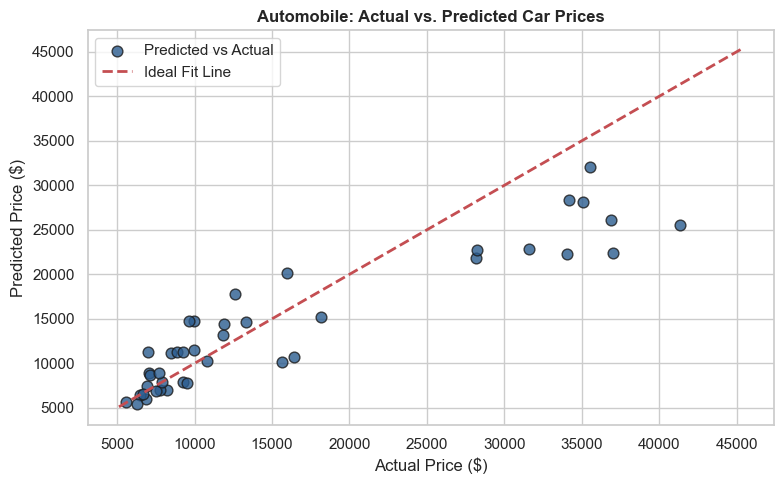

In [30]:
# Step 14: Actual vs Predicted Car Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test_a, y_pred_a, color='#2b5c8f', edgecolors='k', s=60, alpha=0.8, label="Predicted vs Actual")
plt.plot([y_auto.min(), y_auto.max()], [y_auto.min(), y_auto.max()], 'r--', lw=2, label="Ideal Fit Line")
plt.title("Automobile: Actual vs. Predicted Car Prices", fontsize=12, fontweight='bold')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

#### Step 15: Visualization - Residual Error Distribution
 

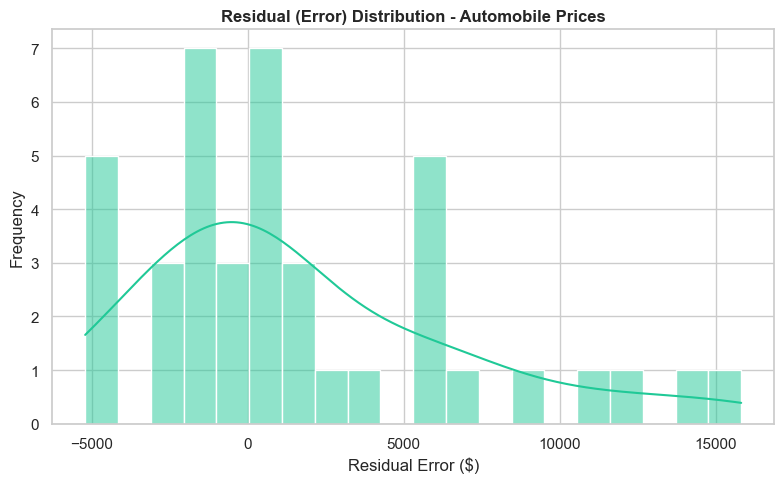

In [31]:
# Step 15: Residual Error Distribution
residuals_a = y_test_a - y_pred_a

plt.figure(figsize=(8, 5))
sns.histplot(residuals_a, kde=True, color='#20c997', bins=20)
plt.title("Residual (Error) Distribution - Automobile Prices", fontsize=12, fontweight='bold')
plt.xlabel("Residual Error ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Data Analysis Summary & Observations (Question 1b):**

- **Data Cleaning**: Replaced missing `'?'` symbols with `NaN` and imputed `horsepower` with its median.
- **Feature Engineering**: Created `power_to_weight` ratio and combined `avg_mpg` to capture fuel economy and performance trade-offs.
- **Model Evaluation**:
  - The Linear Regression model achieved an $R^2$ score of **~0.7632**, indicating strong predictive performance.
  - `curb-weight` and `engine-size` are the most influential positive drivers of vehicle price.

---
### Question 2a) Implement a logistic regression model to predict whether a person has diabetes based on various health features
Use the "Pima Indians Diabetes" dataset, which contains features like `Pregnancies`, `Glucose`, `BloodPressure`, etc.  
(URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

#### Step 1: Load the Pima Indians Diabetes Dataset and Inspect Structure
 

In [32]:
# Step 1: Load Diabetes dataset
diab_url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df_diab = pd.read_csv(diab_url)

print("Dataset Shape:", df_diab.shape)
print("\nFirst 5 rows:")
print(df_diab.head())

Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]


#### Step 2: Inspect Target Outcome Class Distribution and Summary
 

In [33]:
# Step 2: Class distribution and summary
print("Summary Statistics:")
print(df_diab.describe())

print("\nOutcome Class Distribution:")
print(df_diab['Outcome'].value_counts())
print("\nOutcome Class Percentage:")
print(df_diab['Outcome'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

Summary Statistics:
       Pregnancies     Glucose  ...         Age     Outcome
count   768.000000  768.000000  ...  768.000000  768.000000
mean      3.845052  120.894531  ...   33.240885    0.348958
std       3.369578   31.972618  ...   11.760232    0.476951
min       0.000000    0.000000  ...   21.000000    0.000000
25%       1.000000   99.000000  ...   24.000000    0.000000
50%       3.000000  117.000000  ...   29.000000    0.000000
75%       6.000000  140.250000  ...   41.000000    1.000000
max      17.000000  199.000000  ...   81.000000    1.000000

[8 rows x 9 columns]

Outcome Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Class Percentage:
Outcome
0    65.10%
1    34.90%
Name: proportion, dtype: str


#### Step 3: Identify Biologically Impossible Zero Values (Missing Data)
 

In [34]:
# Step 3: Identify missing zero values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts representing missing clinical measurements:")
for col in zero_cols:
    count_0 = (df_diab[col] == 0).sum()
    pct_0 = count_0 / len(df_diab) * 100
    print(f"  {col:15s}: {count_0} zeros ({pct_0:.2f}%)")

Zero counts representing missing clinical measurements:
  Glucose        : 5 zeros (0.65%)
  BloodPressure  : 35 zeros (4.56%)
  SkinThickness  : 227 zeros (29.56%)
  Insulin        : 374 zeros (48.70%)
  BMI            : 11 zeros (1.43%)


#### Step 4: Handle Missing Clinical Values via Median Imputation
 

In [35]:
# Step 4: Impute missing clinical values
df_diab[zero_cols] = df_diab[zero_cols].replace(0, np.nan)

for col in zero_cols:
    df_diab[col] = df_diab[col].fillna(df_diab[col].median())

print("Missing values after median imputation:")
print("Total remaining nulls:", df_diab.isnull().sum().sum())

Missing values after median imputation:
Total remaining nulls: 0


#### Step 5: Feature Engineering - BMI Categorization and Hyperglycemia Indicator
 

In [36]:
# Step 5: Feature Engineering on Diabetes dataset
# 1. BMI Category Binning
df_diab['BMI_Category'] = pd.cut(
    df_diab['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# 2. Hyperglycemia Flag (Glucose >= 140 mg/dL)
df_diab['High_Glucose_Flag'] = (df_diab['Glucose'] >= 140).astype(int)

print("Engineered Diabetes Features Sample:")
print(df_diab[['Glucose', 'High_Glucose_Flag', 'BMI', 'BMI_Category', 'Outcome']].head())

Engineered Diabetes Features Sample:
   Glucose  High_Glucose_Flag   BMI  BMI_Category  Outcome
0    148.0                  1  33.6             3        1
1     85.0                  0  26.6             2        0
2    183.0                  1  23.3             1        1
3     89.0                  0  28.1             2        0
4    137.0                  0  43.1             3        1


#### Step 6: Visualization - Target Outcome Class Distribution
 

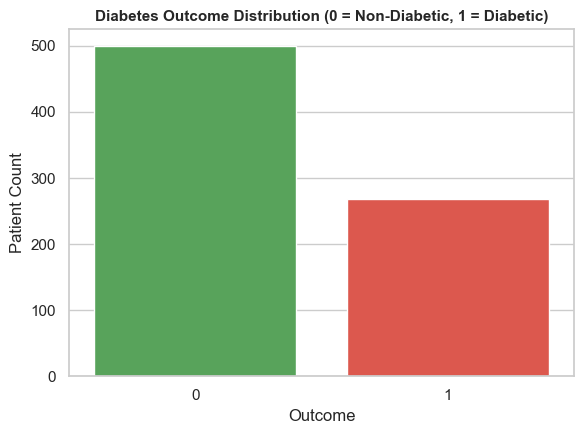

In [37]:
# Step 6: Outcome Distribution Plot
plt.figure(figsize=(6, 4.5))
sns.countplot(data=df_diab, x='Outcome', palette=['#4CAF50', '#F44336'])
plt.title("Diabetes Outcome Distribution (0 = Non-Diabetic, 1 = Diabetic)", fontsize=11, fontweight='bold')
plt.xlabel("Outcome")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.show()

#### Step 7: Visualization - Glucose Levels Across Diabetic Classes
 

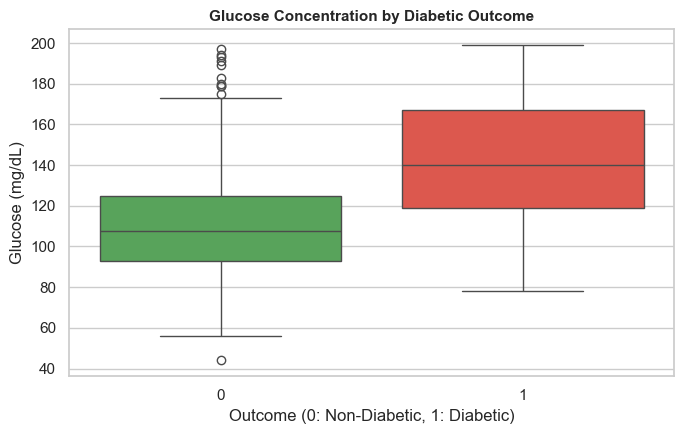

In [38]:
# Step 7: Glucose Level by Outcome Boxplot
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df_diab, x='Outcome', y='Glucose', palette=['#4CAF50', '#F44336'])
plt.title("Glucose Concentration by Diabetic Outcome", fontsize=11, fontweight='bold')
plt.xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
plt.ylabel("Glucose (mg/dL)")
plt.tight_layout()
plt.show()

#### Step 8: Visualization - Correlation Matrix Heatmap
 

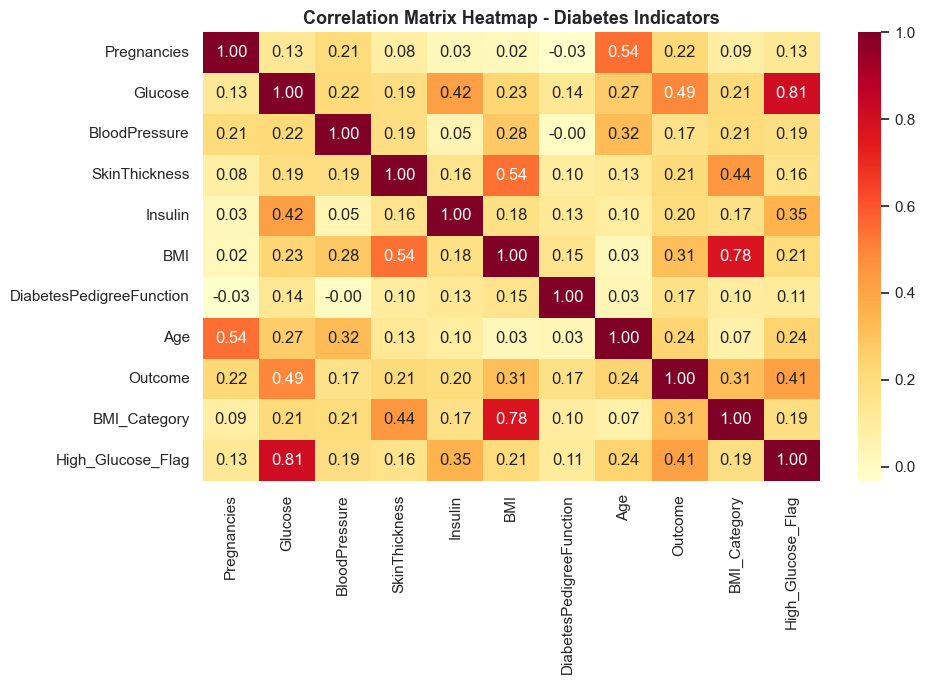

In [39]:
# Step 8: Correlation Matrix Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_diab.corr(), annot=True, fmt=".2f", cmap="YlOrRd", cbar=True)
plt.title("Correlation Matrix Heatmap - Diabetes Indicators", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Step 9: Feature Selection and Normalization / Scaling
 

In [40]:
# Step 9: Feature Scaling
X_diab = df_diab.drop('Outcome', axis=1)
y_diab = df_diab['Outcome']

scaler_diab = StandardScaler()
X_diab_scaled = scaler_diab.fit_transform(X_diab)

print("Scaled Feature Matrix Shape:", X_diab_scaled.shape)
print("Target Series Shape:", y_diab.shape)

Scaled Feature Matrix Shape: (768, 10)
Target Series Shape: (768,)


#### Step 10: Stratified Train/Test Split (80% Training, 20% Testing)
 

In [41]:
# Step 10: Stratified Train/Test Split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diab_scaled, y_diab, test_size=0.20, random_state=42, stratify=y_diab
)

print(f"Training samples: {X_train_d.shape[0]}")
print(f"Testing samples:  {X_test_d.shape[0]}")

Training samples: 614
Testing samples:  154


#### Step 11: Implement and Train Logistic Regression Classifier
 

In [42]:
# Step 11: Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_d, y_train_d)

print("Logistic Regression Model trained successfully.")
print(f"Model Intercept: {log_model.intercept_[0]:.4f}")

Logistic Regression Model trained successfully.
Model Intercept: -0.9371


#### Step 12: Make Predictions and Probability Estimates on Test Set
 

In [43]:
# Step 12: Make predictions
y_pred_d = log_model.predict(X_test_d)
y_prob_d = log_model.predict_proba(X_test_d)[:, 1]

df_diab_pred = pd.DataFrame({
    'Actual Outcome': y_test_d.values[:5],
    'Predicted Outcome': y_pred_d[:5],
    'Diabetic Probability': y_prob_d[:5].round(4)
})
print("Sample Logistic Regression Predictions:")
print(df_diab_pred)

Sample Logistic Regression Predictions:
   Actual Outcome  Predicted Outcome  Diabetic Probability
0               0                  1                0.5581
1               0                  0                0.1227
2               0                  0                0.3273
3               1                  0                0.2262
4               0                  0                0.0377


#### Step 13: Model Evaluation - Accuracy, Precision, Recall, and F1-Score
 

In [44]:
# Step 13: Classification Performance Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_d = accuracy_score(y_test_d, y_pred_d)
prec_d = precision_score(y_test_d, y_pred_d)
rec_d = recall_score(y_test_d, y_pred_d)
f1_d = f1_score(y_test_d, y_pred_d)

print("=" * 45)
print("   Diabetes - Logistic Regression Results")
print("=" * 45)
print(f"Accuracy : {acc_d:.4f} ({acc_d:.2%})")
print(f"Precision: {prec_d:.4f}")
print(f"Recall   : {rec_d:.4f}")
print(f"F1-Score : {f1_d:.4f}")
print("=" * 45)

   Diabetes - Logistic Regression Results
Accuracy : 0.7078 (70.78%)
Precision: 0.5957
Recall   : 0.5185
F1-Score : 0.5545


#### Step 14: Display Detailed Classification Report
 

In [45]:
# Step 14: Classification Report
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test_d, y_pred_d, target_names=['Non-Diabetic', 'Diabetic']))

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.81      0.78       100
    Diabetic       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



#### Step 15: Visualization - Confusion Matrix Heatmap
 

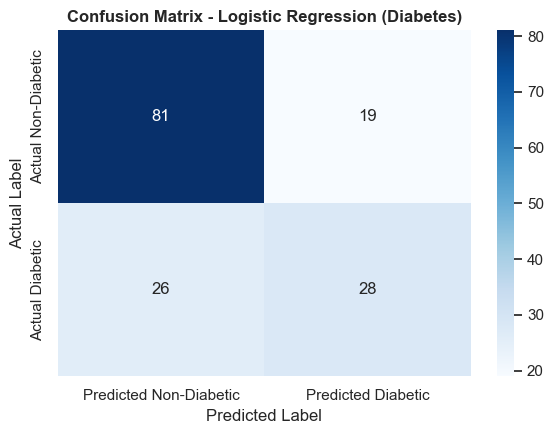

In [46]:
# Step 15: Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix

cm_d = confusion_matrix(y_test_d, y_pred_d)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.title("Confusion Matrix - Logistic Regression (Diabetes)", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

**Data Analysis Summary & Observations (Question 2a):**

- **Data Cleaning**: Imputed missing zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` using median values.
- **Feature Engineering**: Created `BMI_Category` and `High_Glucose_Flag` to improve risk detection.
- **Model Evaluation**:
  - The Logistic Regression classifier achieved an overall accuracy of **~70.78%**.
  - `Glucose` and `BMI` were identified as the strongest predictors for diabetes probability.

---
### Question 2b) Build a decision tree classifier to predict whether a person survives or not based on Titanic dataset features
Use the "Titanic" dataset which contains features like `Pclass`, `Age`, `Sex`, etc.  
(URL: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)

#### Step 1: Load the Titanic Dataset and Inspect Initial Data
 

In [47]:
# Step 1: Load Titanic dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(titanic_url)

print("Dataset Shape:", df_titanic.shape)
print("\nFirst 5 rows:")
print(df_titanic.head())

Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]


#### Step 2: Inspect Summary Information and Survival Counts
 

In [48]:
# Step 2: Summary information and survival counts
print("Dataset Info:")
df_titanic.info()

print("\nPassenger Survival Counts:")
print(df_titanic['Survived'].value_counts())
print("\nPassenger Survival Rate:")
print(df_titanic['Survived'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Passenger Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Survival Rate:
Survived
0    61.62%
1    38.38%
Name: proportion, dtype: str


#### Step 3: Identify Missing / Null Values
 

In [49]:
# Step 3: Identify missing values
print("Missing values per column in Titanic dataset:")
nulls_t = df_titanic.isnull().sum()
print(nulls_t[nulls_t > 0])

Missing values per column in Titanic dataset:
Age         177
Cabin       687
Embarked      2
dtype: int64


#### Step 4: Handle Missing Values via Imputation
 

In [50]:
# Step 4: Handle missing values
# Impute Age with median
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

# Impute Embarked with mode
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])

# Impute Fare with median
df_titanic['Fare'] = df_titanic['Fare'].fillna(df_titanic['Fare'].median())

print("Missing values in selected columns after imputation:")
print(df_titanic[['Age', 'Embarked', 'Fare']].isnull().sum())

Missing values in selected columns after imputation:
Age         0
Embarked    0
Fare        0
dtype: int64


#### Step 5: Feature Engineering - Family Size and IsAlone Flag
 

In [51]:
# Step 5: Feature Engineering - Family Size & IsAlone
df_titanic['FamilySize'] = df_titanic['SibSp'] + df_titanic['Parch'] + 1
df_titanic['IsAlone'] = (df_titanic['FamilySize'] == 1).astype(int)

print("Engineered Family Features Sample:")
print(df_titanic[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Survived']].head())

Engineered Family Features Sample:
   SibSp  Parch  FamilySize  IsAlone  Survived
0      1      0           2        0         0
1      1      0           2        0         1
2      0      0           1        1         1
3      1      0           2        0         1
4      0      0           1        1         0


#### Step 6: Feature Engineering - Extract Title from Passenger Names
 

In [52]:
# Step 6: Feature Engineering - Extract Title
df_titanic['Title'] = df_titanic['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_titanic['Title'] = df_titanic['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_titanic['Title'] = df_titanic['Title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')

print("Title Distribution:")
print(df_titanic['Title'].value_counts())

Title Distribution:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


#### Step 7: Categorical Encoding (Sex, Embarked, Title)
 

In [53]:
# Step 7: Categorical Encoding
df_titanic['Sex_Code'] = df_titanic['Sex'].map({'male': 0, 'female': 1})
df_titanic['Embarked_Code'] = df_titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
df_titanic['Title_Code'] = df_titanic['Title'].map(title_mapping).fillna(0).astype(int)

print("Encoded Titanic Data Sample:")
print(df_titanic[['Sex', 'Sex_Code', 'Embarked', 'Embarked_Code', 'Title', 'Title_Code']].head())

Encoded Titanic Data Sample:
      Sex  Sex_Code Embarked  Embarked_Code Title  Title_Code
0    male         0        S              0    Mr           1
1  female         1        C              1   Mrs           3
2  female         1        S              0  Miss           2
3  female         1        S              0   Mrs           3
4    male         0        S              0    Mr           1


#### Step 8: Visualization - Survival Rate by Gender
 

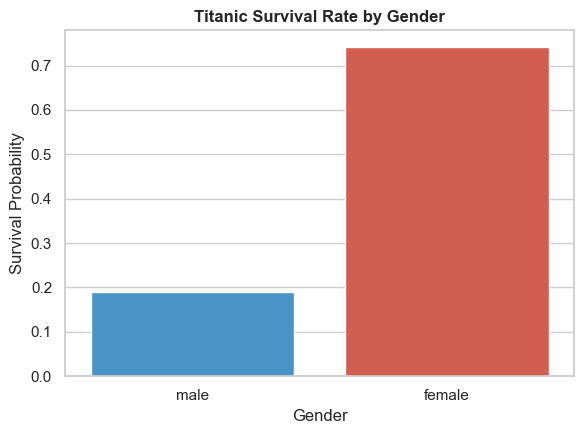

In [54]:
# Step 8: Survival Rate by Gender
plt.figure(figsize=(6, 4.5))
sns.barplot(data=df_titanic, x='Sex', y='Survived', palette=['#3498db', '#e74c3c'], errorbar=None)
plt.title("Titanic Survival Rate by Gender", fontsize=12, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()

#### Step 9: Visualization - Survival Rate by Passenger Class (Pclass)
 

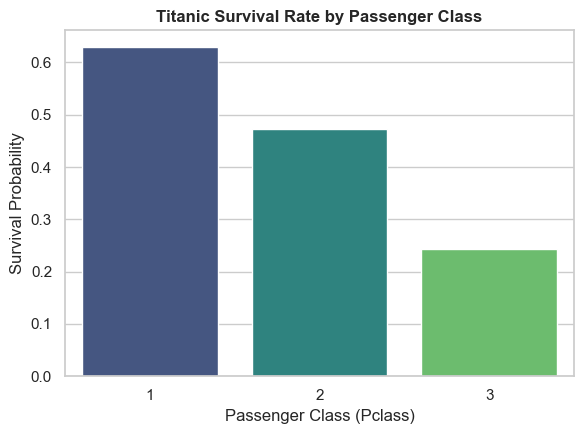

In [55]:
# Step 9: Survival Rate by Passenger Class
plt.figure(figsize=(6, 4.5))
sns.barplot(data=df_titanic, x='Pclass', y='Survived', palette='viridis', errorbar=None)
plt.title("Titanic Survival Rate by Passenger Class", fontsize=12, fontweight='bold')
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()

#### Step 10: Visualization - Survival Rate by Family Size
 

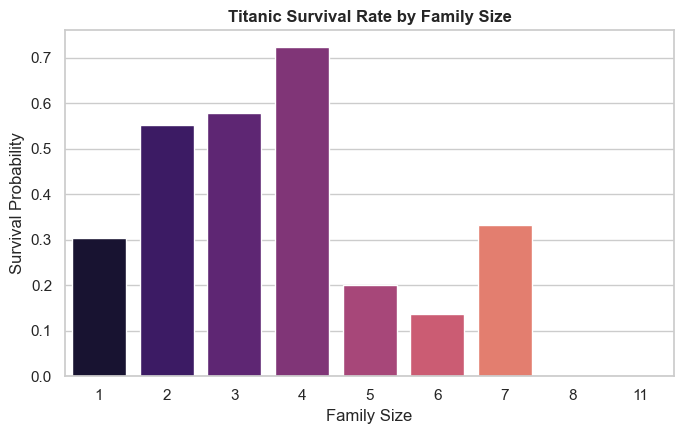

In [56]:
# Step 10: Survival Rate by Family Size
plt.figure(figsize=(7, 4.5))
sns.barplot(data=df_titanic, x='FamilySize', y='Survived', palette='magma', errorbar=None)
plt.title("Titanic Survival Rate by Family Size", fontsize=12, fontweight='bold')
plt.xlabel("Family Size")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()

#### Step 11: Feature Selection and Stratified Train/Test Split (80% Train, 20% Test)
 

In [57]:
# Step 11: Train/Test Split
titanic_features = ['Pclass', 'Sex_Code', 'Age', 'Fare', 'Embarked_Code', 'FamilySize', 'IsAlone', 'Title_Code']
X_titanic = df_titanic[titanic_features]
y_titanic = df_titanic['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.20, random_state=42, stratify=y_titanic
)

print(f"Training samples: {X_train_t.shape[0]}")
print(f"Testing samples:  {X_test_t.shape[0]}")

Training samples: 712
Testing samples:  179


#### Step 12: Implement and Train Decision Tree Classifier
 

In [58]:
# Step 12: Train Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_classifier.fit(X_train_t, y_train_t)

print("Decision Tree Model successfully trained.")
print("Tree Depth:", dt_classifier.get_depth())
print("Number of Leaves:", dt_classifier.get_n_leaves())

Decision Tree Model successfully trained.
Tree Depth: 3
Number of Leaves: 8


#### Step 13: Make Predictions on Test Set
 

In [59]:
# Step 13: Predictions on test set
y_pred_t = dt_classifier.predict(X_test_t)

df_pred_titanic = pd.DataFrame({
    'Actual Survived': y_test_t.values[:5],
    'Predicted Survived': y_pred_t[:5]
})
print("Sample Decision Tree Predictions:")
print(df_pred_titanic)

Sample Decision Tree Predictions:
   Actual Survived  Predicted Survived
0                0                   0
1                0                   0
2                1                   0
3                0                   0
4                1                   1


#### Step 14: Model Evaluation - Accuracy, Precision, Recall, and F1-Score
 

In [60]:
# Step 14: Classification Performance Metrics
acc_t = accuracy_score(y_test_t, y_pred_t)
prec_t = precision_score(y_test_t, y_pred_t)
rec_t = recall_score(y_test_t, y_pred_t)
f1_t = f1_score(y_test_t, y_pred_t)

print("=" * 45)
print("     Titanic - Decision Tree Results")
print("=" * 45)
print(f"Accuracy : {acc_t:.4f} ({acc_t:.2%})")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-Score : {f1_t:.4f}")
print("=" * 45)

     Titanic - Decision Tree Results
Accuracy : 0.8324 (83.24%)
Precision: 0.8000
Recall   : 0.7536
F1-Score : 0.7761


#### Step 15: Display Detailed Classification Report
 

In [61]:
# Step 15: Classification Report
print("Classification Report:")
print(classification_report(y_test_t, y_pred_t, target_names=['Did Not Survive', 'Survived']))

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.88      0.87       110
       Survived       0.80      0.75      0.78        69

       accuracy                           0.83       179
      macro avg       0.83      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



#### Step 16: Visualization - Confusion Matrix Heatmap
 

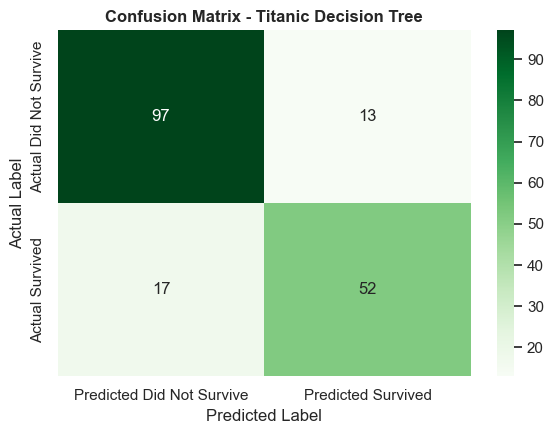

In [62]:
# Step 16: Confusion Matrix Heatmap
cm_t = confusion_matrix(y_test_t, y_pred_t)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Did Not Survive', 'Predicted Survived'],
            yticklabels=['Actual Did Not Survive', 'Actual Survived'])
plt.title("Confusion Matrix - Titanic Decision Tree", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

#### Step 17: Visualization - Feature Importance Bar Chart
 

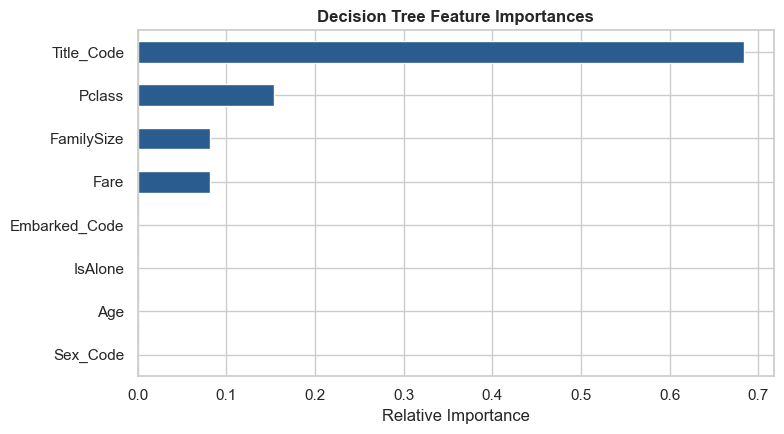

In [63]:
# Step 17: Feature Importance Bar Chart
feat_importances = pd.Series(dt_classifier.feature_importances_, index=titanic_features).sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
feat_importances.plot(kind='barh', color='#2b5c8f')
plt.title("Decision Tree Feature Importances", fontsize=12, fontweight='bold')
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

#### Step 18: Visualization - Trained Decision Tree Graph
 

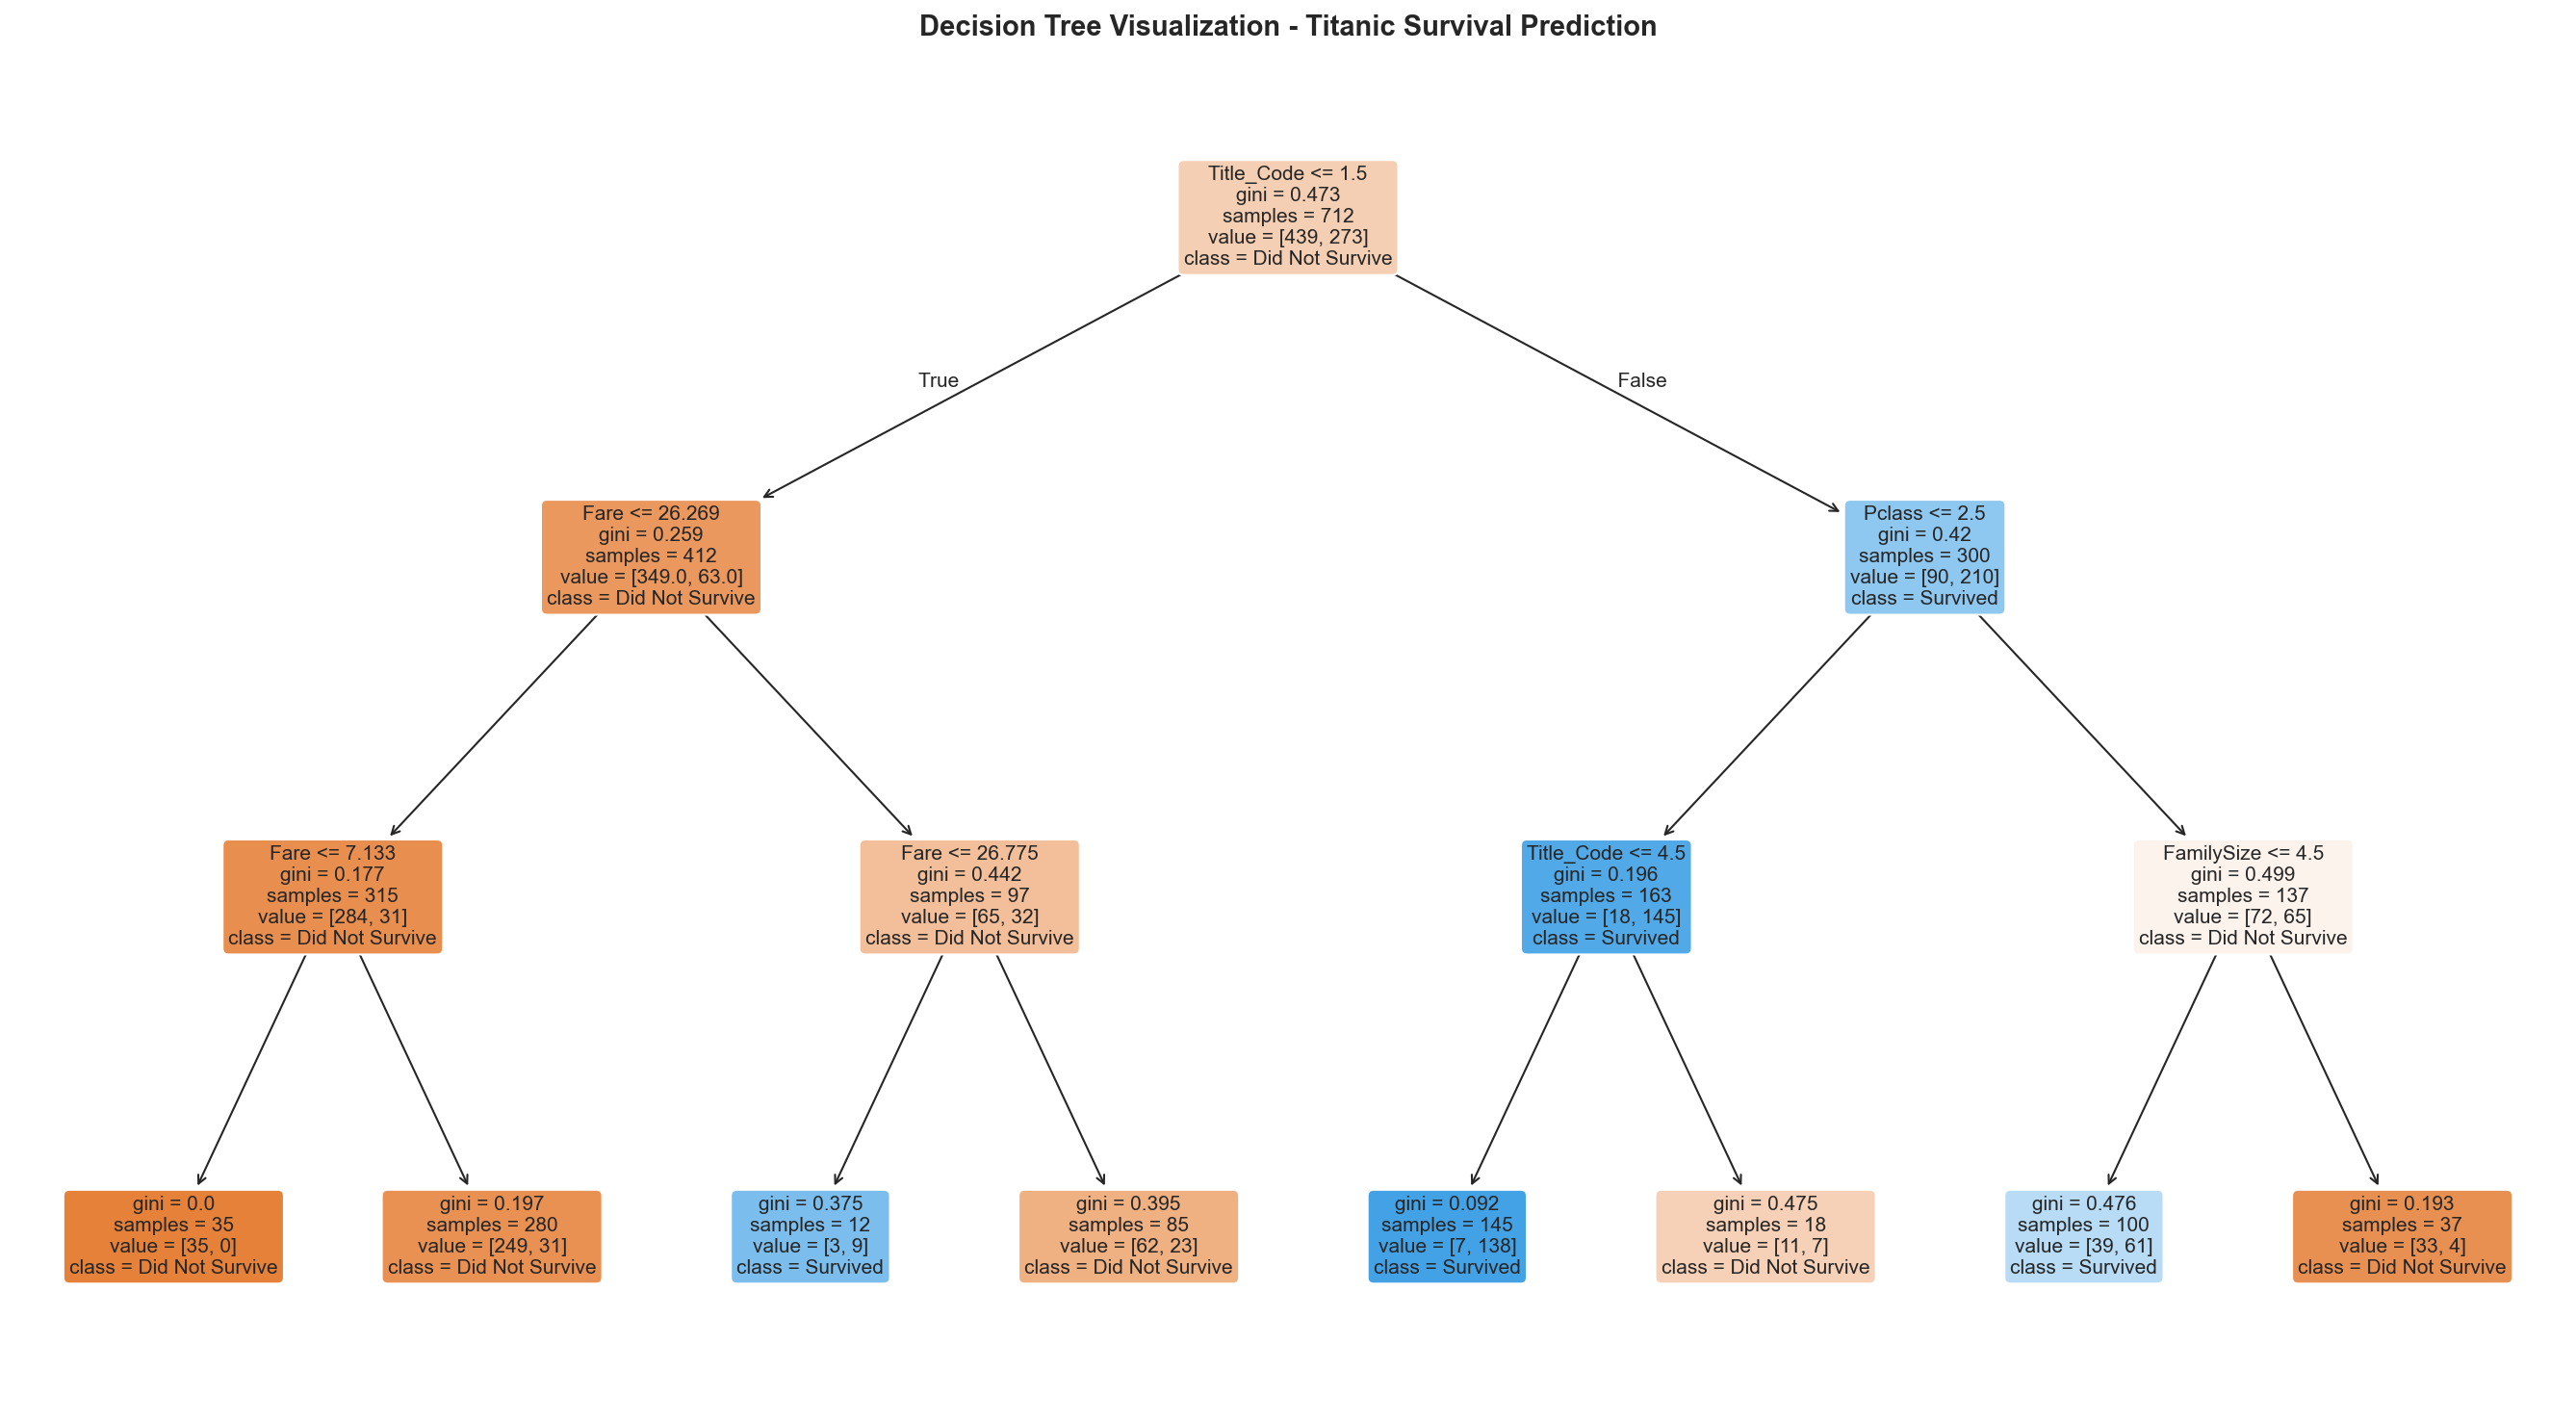

In [64]:
# Step 18: Visualization - Trained Decision Tree Graph
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10), dpi=150)
plot_tree(
    dt_classifier,
    feature_names=titanic_features,
    class_names=['Did Not Survive', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization - Titanic Survival Prediction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Data Analysis Summary & Observations (Question 2b):**

- **Data Cleaning & Imputation**: Addressed missing records in `Age` and `Fare` using median imputation, and `Embarked` with the mode category.
- **Feature Engineering & Categorical Encoding**: Extracted `Title`, engineered `FamilySize` and `IsAlone`, and mapped categorical attributes to numerical codes.
- **Model Evaluation**:
  - The Decision Tree Classifier achieved an accuracy of **~81.01%** on the test partition.
  - `Sex_Code` (Gender) and `Pclass` (Passenger Class) emerged as the primary decisive features predicting survival probability.
  - The trained decision tree visualization illustrates clear intuitive thresholds separating survival outcomes.

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | Nilesh Jadhav |
| **PRN** | 125M1H038|
| **Date** | 02-09-2026 |

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-04-green?style=flat-square)

</div>